<a href="https://colab.research.google.com/github/shalini6123/Pavi1404/blob/main/AI_tools_adoption_trend_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

phase 1: Data understanding

Objectives:

Load dataset,
Understand variables,
Check missing values,
Remove duplicates,
Study distributions.

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('AI_Tools_Adoption_Trend_Analysis_Dataset.csv')


print(df.head())


print("Shape:", df.shape)


print(df.info())


print(df.isnull().sum())


print("Duplicates:", df.duplicated().sum())


df = df.drop_duplicates()


print(df.describe())

   Year  Country       Industry         AI_Tool  Adoption_Rate  \
0  2025       UK  Manufacturing         ChatGPT          33.40   
1  2026  Germany         Retail         ChatGPT          94.20   
2  2023   Canada      Education  GitHub Copilot          43.83   
3  2025       UK  Manufacturing  GitHub Copilot          83.28   
4  2025    India     Healthcare  GitHub Copilot          85.69   

   Daily_Active_Users Company_Size Age_Group  
0               99391        Small     26-35  
1               63754       Medium     26-35  
2               17844        Small     18-25  
3               23534       Medium     26-35  
4               48101        Large     26-35  
Shape: (5000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                5000 non-null   int64  
 1   Country             5000 non-null   object 
 2

Phase:2 Descriptive statistical analysis

Objectives

Calculate:

Mean,
Median,
Standard Deviation,
Quartiles,
Percentiles.


In [ ]:

print(df.mean(numeric_only=True))


print(df.median(numeric_only=True))


print(df.std(numeric_only=True))

print(df.quantile([0.25,0.50,0.75], numeric_only=True))

print(np.percentile(df['Adoption_Rate'], [10,25,50,75,90]))

Year                   2024.485200
Adoption_Rate            49.772638
Daily_Active_Users    50078.200600
dtype: float64
Year                   2024.000
Adoption_Rate            49.525
Daily_Active_Users    50195.000
dtype: float64
Year                      1.127136
Adoption_Rate            25.834860
Daily_Active_Users    28805.183379
dtype: float64
        Year  Adoption_Rate  Daily_Active_Users
0.25  2023.0        27.2875            24652.25
0.50  2024.0        49.5250            50195.00
0.75  2026.0        71.4250            75143.00
[14.6    27.2875 49.525  71.425  86.061 ]


phase3: Trend Investigation

Objectives

Analyze:

Industry vs Adoption,
Company Size vs Adoption,
AI Tool vs Satisfaction,
Adoption Year vs Growth,
Employee Count vs AI Usage.

Industry
Education        51.068358
Finance          49.515284
Healthcare       51.702313
IT               47.827162
Manufacturing    50.579773
Retail           48.134583
Name: Adoption_Rate, dtype: float64
Company_Size
Large     49.971474
Medium    49.878854
Small     49.483514
Name: Adoption_Rate, dtype: float64
Year
2023    50.146386
2024    48.997871
2025    50.017246
2026    49.916728
Name: Adoption_Rate, dtype: float64


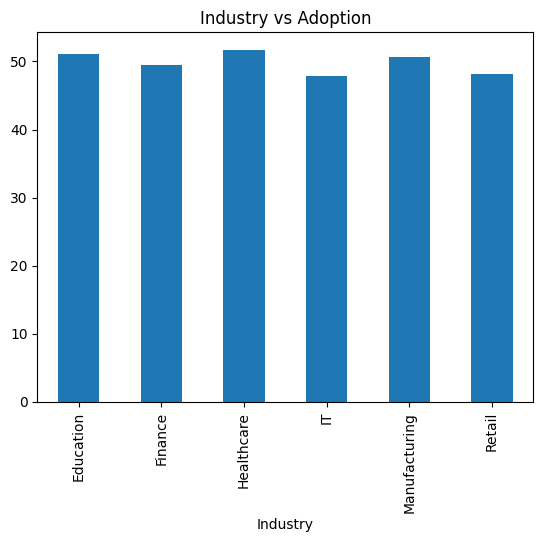

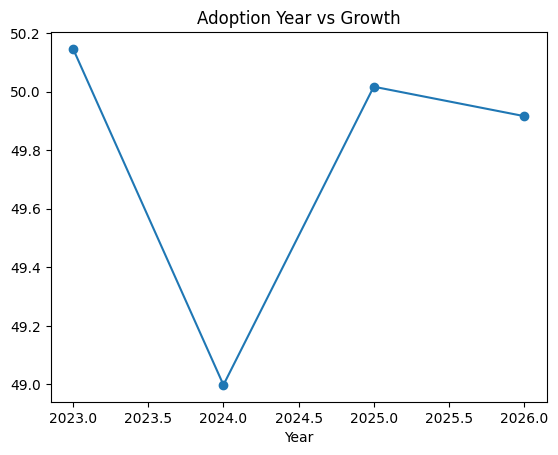

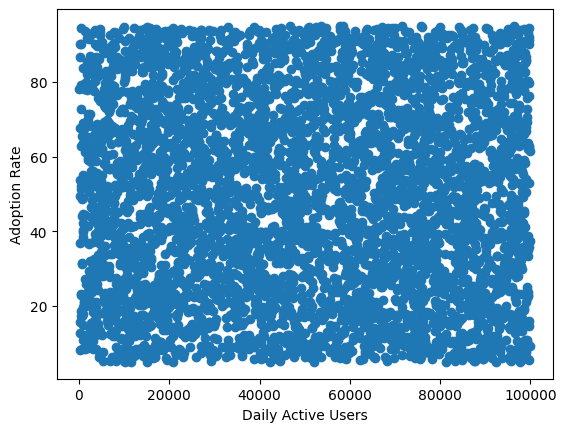

In [ ]:

industry_adoption = df.groupby('Industry')['Adoption_Rate'].mean()
print(industry_adoption)


company_adoption = df.groupby('Company_Size')['Adoption_Rate'].mean()
print(company_adoption)


year_growth = df.groupby('Year')['Adoption_Rate'].mean()
print(year_growth)

industry_adoption.plot(kind='bar')
plt.title('Industry vs Adoption')
plt.show()


year_growth.plot(marker='o')
plt.title('Adoption Year vs Growth')
plt.show()

plt.scatter(df['Daily_Active_Users'], df['Adoption_Rate'])
plt.xlabel('Daily Active Users')
plt.ylabel('Adoption Rate')
plt.show()

Phase4: Correlation analysis

Objectives

Study Relationships:

Adoption vs Productivity,
Tool Usage vs Satisfaction,
Employee Count vs Adoption,
AI Investment vs Savings.

                        Year  Adoption_Rate  Daily_Active_Users
Year                1.000000       0.001193            0.010311
Adoption_Rate       0.001193       1.000000           -0.013529
Daily_Active_Users  0.010311      -0.013529            1.000000


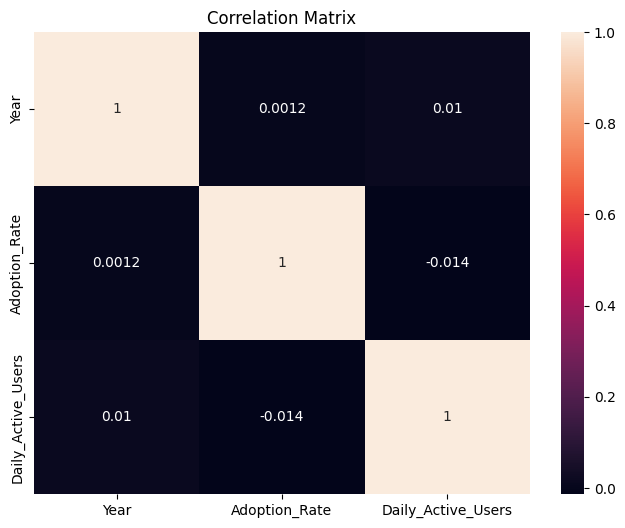

In [ ]:

numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

print(corr)


plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Correlation Matrix")
plt.show()

phase5:hypothesis testing

Hypothesis

H₀: Company size has no impact on AI adoption.

H₁: Company size significantly impacts AI adoption

In [ ]:
from scipy.stats import f_oneway

small = df[df['Company_Size']=='Small']['Adoption_Rate']
medium = df[df['Company_Size']=='Medium']['Adoption_Rate']
large = df[df['Company_Size']=='Large']['Adoption_Rate']

f_stat,p_value = f_oneway(small,medium,large)

print("F Statistic:",f_stat)
print("P Value:",p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

F Statistic: 0.1717146003632422
P Value: 0.842224477501951
Fail to Reject Null Hypothesis


phase6: organization segmentation

Categories:
AI Leaders,
Early Adopters,
Slow Adopters,
High Satisfaction Organizations,
High ROI Organizations.

Segment
Slow Adopters     3098
Early Adopters    1074
AI Leaders         828
Name: count, dtype: int64


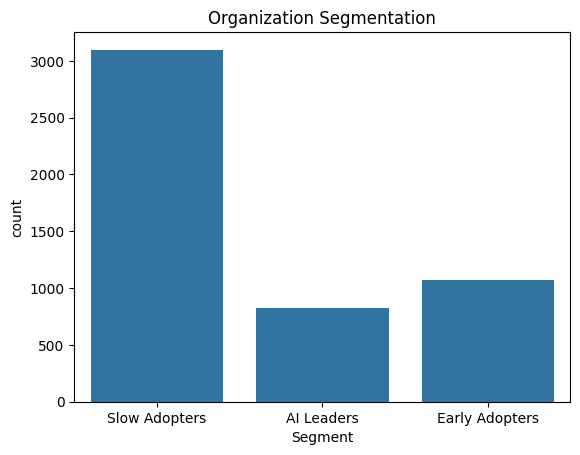

In [ ]:
def segment(x):
    if x >= 80:
        return "AI Leaders"
    elif x >= 60:
        return "Early Adopters"
    else:
        return "Slow Adopters"

df['Segment'] = df['Adoption_Rate'].apply(segment)

print(df['Segment'].value_counts())
sns.countplot(x='Segment', data=df)
plt.title("Organization Segmentation")
plt.show()

phase7: Business insights

In [ ]:
print("Most Used AI Tool:")
print(df['AI_Tool'].value_counts().head(1))

print("\nTop Industry:")
print(df.groupby('Industry')['Adoption_Rate'].mean().sort_values(ascending=False).head(1))

print("\nTop Country:")
print(df.groupby('Country')['Adoption_Rate'].mean().sort_values(ascending=False).head(1))

Most Used AI Tool:
AI_Tool
Gemini    1030
Name: count, dtype: int64

Top Industry:
Industry
Healthcare    51.702313
Name: Adoption_Rate, dtype: float64

Top Country:
Country
Australia    50.810724
Name: Adoption_Rate, dtype: float64


Github